# Retail Cohort Retention and Order Value

Product question: how quickly do new retail customers come back after their first purchase?
Sample transaction table modeled after a typical online-retail export; returns and price outliers are kept for cleaning practice.
Main checks: monthly cohort retention, order-value distribution, and early-cohort revenue differences.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [ ]:
raw_data = pd.read_csv('../data/online_retail.csv')
print("shape:", raw_data.shape)
raw_data.head()


shape: (30000, 6)


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,505559,167,2024-01-01,9.71,13113,United Kingdom
1,575619,42,2024-01-01,1.83,16912,United Kingdom
2,534799,112,2024-01-01,1.80,15417,Germany
3,571764,187,2024-01-01,15.94,12392,United Kingdom
4,502731,62,2024-01-01,0.53,13837,United Kingdom


In [ ]:
raw_data.isnull().sum()


InvoiceNo      0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

returns/cancellations have negative quantities. some unit prices might be outliers or errors.
clean this up.

In [ ]:
print("negative quantities:", (raw_data['Quantity'] < 0).sum())
print("zero or negative prices:", (raw_data['UnitPrice'] <= 0).sum())
raw_data['UnitPrice'].describe()


negative quantities: 715
zero or negative prices: 0


count    30000.000000
mean         5.927354
std         17.519374
min          0.500000
25%          1.940000
50%          3.970000
75%          7.420000
max        885.244544
Name: UnitPrice, dtype: float64

In [ ]:
q1 = raw_data['UnitPrice'].quantile(0.25)
q3 = raw_data['UnitPrice'].quantile(0.75)
iqr = q3 - q1
upper_fence = q3 + 3.0 * iqr
print("upper price fence:", round(upper_fence, 2))

df_clean = raw_data[(raw_data['Quantity'] > 0) & (raw_data['UnitPrice'] > 0) & (raw_data['UnitPrice'] <= upper_fence)].copy()
df_clean.shape


upper price fence: 23.86


(28838, 6)

In [ ]:
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean.head(3)


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceMonth
0,505559,167,2024-01-01,9.71,13113,United Kingdom,2024-01
1,575619,42,2024-01-01,1.83,16912,United Kingdom,2024-01
2,534799,112,2024-01-01,1.80,15417,Germany,2024-01


### cohort assignment
assign each customer to their cohort month (first invoice date).

In [ ]:
df_clean['CohortMonth'] = df_clean.groupby('CustomerID')['InvoiceDate'].transform('min').dt.to_period('M')
df_clean['CohortIndex'] = (df_clean['InvoiceMonth'] - df_clean['CohortMonth']).apply(lambda x: x.n)
df_clean[['CustomerID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].drop_duplicates().head(7)


,CustomerID,InvoiceMonth,CohortMonth,CohortIndex
0,13113,2024-01,2024-01,0
1,16912,2024-01,2024-01,0
2,15417,2024-01,2024-01,0
3,12392,2024-01,2024-01,0
4,13837,2024-01,2024-01,0
5,16434,2024-01,2024-01,0
6,15095,2024-01,2024-01,0


In [ ]:
cohort_counts = df_clean.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')
cohort_sizes = cohort_pivot[0]
cohort_ret_pct = cohort_pivot.divide(cohort_sizes, axis=0)
cohort_ret_pct.index = cohort_ret_pct.index.astype(str)
cohort_ret_pct.round(3)


CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11
CohortMonth,,,,,,,,,,,,
2024-01,1.0,0.356,0.381,0.368,0.388,0.379,0.399,0.385,0.375,0.383,0.385,0.381
2024-02,1.0,0.377,0.378,0.390,0.400,0.372,0.408,0.371,0.397,0.371,0.374,NaN
2024-03,1.0,0.417,0.367,0.329,0.391,0.399,0.388,0.393,0.370,0.390,NaN,NaN
2024-04,1.0,0.409,0.350,0.400,0.374,0.365,0.368,0.368,0.383,NaN,NaN,NaN
2024-05,1.0,0.407,0.429,0.407,0.393,0.378,0.407,0.316,NaN,NaN,NaN,NaN
2024-06,1.0,0.387,0.423,0.423,0.393,0.417,0.381,NaN,NaN,NaN,NaN,NaN
2024-07,1.0,0.409,0.382,0.345,0.382,0.418,NaN,NaN,NaN,NaN,NaN,NaN
2024-08,1.0,0.377,0.396,0.453,0.302,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09,1.0,0.377,0.226,0.302,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


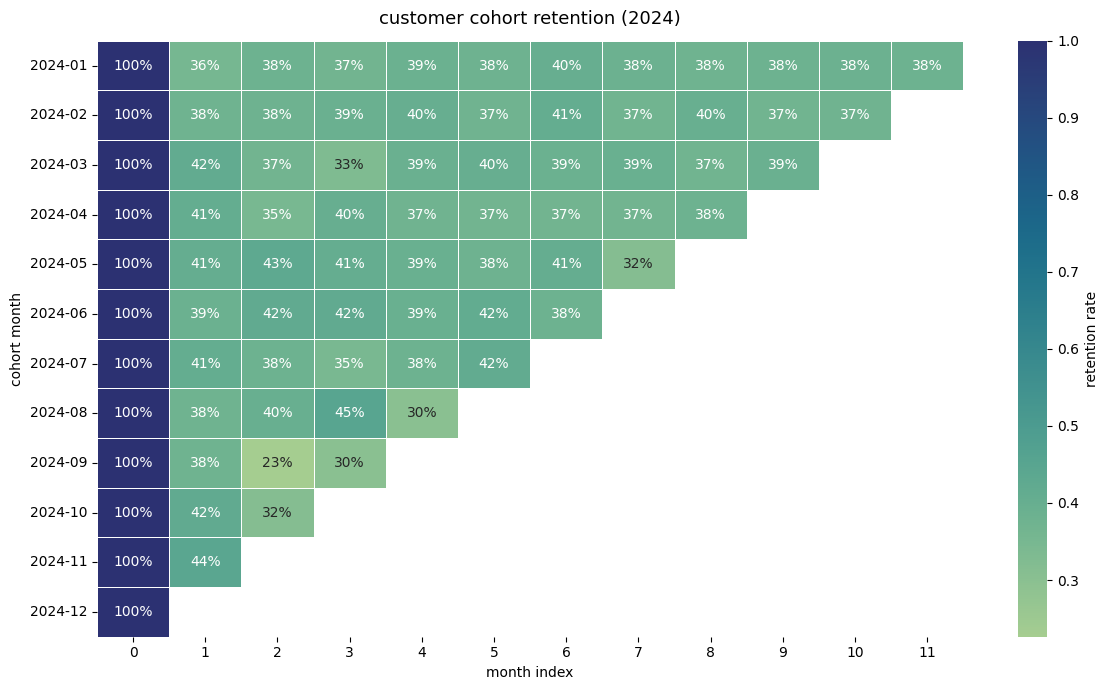

In [ ]:
import seaborn as sns
plt.figure(figsize=(12, 7))
sns.heatmap(cohort_ret_pct, annot=True, fmt='.0%', cmap='crest', linewidths=.5, cbar_kws={'label': 'retention rate'})
plt.title('customer cohort retention (2024)', fontsize=13, pad=12)
plt.xlabel('month index')
plt.ylabel('cohort month')
plt.tight_layout()
plt.show()


the month 1 drop is quite sharp across all cohorts (around 80-90% drop).
plot the average decay curve.

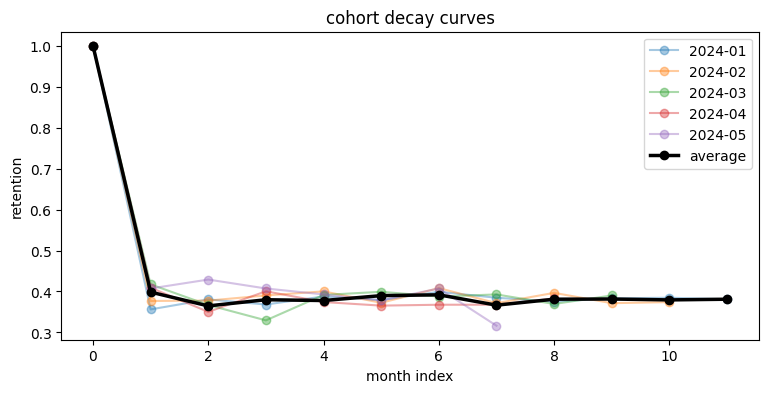

In [ ]:
avg_decay = cohort_ret_pct.mean()
plt.figure(figsize=(9, 4))
for cohort in cohort_ret_pct.index[:5]:
    plt.plot(cohort_ret_pct.columns, cohort_ret_pct.loc[cohort], marker='o', alpha=0.4, label=cohort)
plt.plot(avg_decay.index, avg_decay.values, color='black', linewidth=2.5, marker='o', label='average')
plt.title('cohort decay curves')
plt.xlabel('month index')
plt.ylabel('retention')
plt.legend()
plt.show()


now check order revenues. are there significant differences in average order revenue across the first 3 cohorts (Jan, Feb, Mar)?
calculate order values.

In [ ]:
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']
orders_rev = df_clean.groupby(['InvoiceNo', 'CohortMonth'])['Revenue'].sum().reset_index()
orders_rev['CohortMonth'] = orders_rev['CohortMonth'].astype(str)
orders_rev.head()


,InvoiceNo,CohortMonth,Revenue
0,500003,2024-04,416.24
1,500006,2024-02,302.88
2,500007,2024-01,63.52
3,500010,2024-08,3180.87
4,500013,2024-01,1061.06


In [ ]:
orders_rev['Revenue'].describe()


count    27699.000000
mean       551.010895
std        615.510997
min          0.570000
25%        131.060000
50%        332.820000
75%        742.660000
max       6000.920000
Name: Revenue, dtype: float64

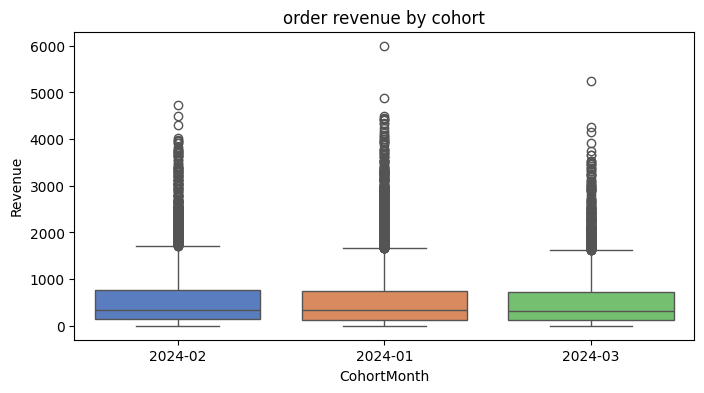

In [ ]:
import scipy.stats as stats
target_cohorts = ['2024-01', '2024-02', '2024-03']
sub_df = orders_rev[orders_rev['CohortMonth'].isin(target_cohorts)]

import seaborn as sns
plt.figure(figsize=(8, 4))
sns.boxplot(data=sub_df, x='CohortMonth', y='Revenue', palette='muted', hue='CohortMonth', legend=False)
plt.title('order revenue by cohort')
plt.show()


In [ ]:
anova_groups = [sub_df[sub_df['CohortMonth'] == c]['Revenue'].values for c in target_cohorts]
f_stat, p_val = stats.f_oneway(*anova_groups)
print(f"ANOVA F-stat: {f_stat:.4f}  p-val: {p_val:.4f}")


ANOVA F-stat: 3.5872  p-val: 0.0277


In [ ]:
levene_stat, levene_p = stats.levene(*anova_groups, center='median')
kruskal_stat, kruskal_p = stats.kruskal(*anova_groups)
print(f"Levene/Brown-Forsythe statistic: {levene_stat:.4f}  p-value: {levene_p:.4f}")
print(f"Kruskal-Wallis H statistic: {kruskal_stat:.4f}  p-value: {kruskal_p:.4f}")


Levene/Brown-Forsythe statistic: 2.7610  p-value: 0.0633
Kruskal-Wallis H statistic: 5.5908  p-value: 0.0611


With one categorical factor, ANOVA typ=2 gives the same decision as typ=1/3 for this setup. Type choice becomes important in multi-factor or interaction models.

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

anova_model = ols('Revenue ~ C(CohortMonth)', data=sub_df).fit()
print(sm.stats.anova_lm(anova_model, typ=2))


                      sum_sq       df         F    PR(>F)
C(CohortMonth)  2.716778e+06      2.0  3.587213  0.027691
Residual        8.582296e+09  22664.0       NaN       NaN


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
tukey = pairwise_tukeyhsd(sub_df['Revenue'], sub_df['CohortMonth'])
print(tukey)


  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower    upper  reject
-------------------------------------------------------
2024-01 2024-02   2.4883 0.9628 -19.7447 24.7213  False
2024-01 2024-03 -26.9434 0.0374 -52.6518  -1.235   True
2024-02 2024-03 -29.4317 0.0398 -57.7929 -1.0705   True
-------------------------------------------------------


ANOVA flags a small difference in mean order revenue, and Tukey points to March being lower than January/February.
Because revenue is skewed and the Kruskal-Wallis result is only borderline, this should be treated as weak evidence rather than a pricing anomaly by itself.